Running 60 jobs across 10 threads...
  [1/60]  d=3  p=1.27e-03  LER=1.660e-03
  [2/60]  d=3  p=1.83e-03  LER=3.340e-03
  [3/60]  d=3  p=2.64e-03  LER=6.020e-03
  [4/60]  d=3  p=3.79e-03  LER=1.228e-02
  [5/60]  d=3  p=5.46e-03  LER=2.418e-02
  [6/60]  d=3  p=8.86e-04  LER=1.033e-03
  [7/60]  d=3  p=1.13e-02  LER=7.962e-02
  [8/60]  d=3  p=2.98e-04  LER=1.857e-04
  [9/60]  d=3  p=1.62e-02  LER=1.364e-01
  [10/60]  d=3  p=7.85e-03  LER=4.258e-02
  [11/60]  d=3  p=1.00e-04  LER=4.600e-05
  [12/60]  d=3  p=4.83e-02  LER=4.128e-01
  [13/60]  d=3  p=6.95e-02  LER=4.697e-01
  [14/60]  d=3  p=2.34e-02  LER=2.228e-01
  [15/60]  d=3  p=1.00e-01  LER=4.905e-01
  [16/60]  d=3  p=4.28e-04  LER=2.857e-04
  [17/60]  d=3  p=2.07e-04  LER=1.040e-04
  [18/60]  d=3  p=3.36e-02  LER=3.218e-01
  [19/60]  d=3  p=1.44e-04  LER=8.200e-05
  [20/60]  d=3  p=6.16e-04  LER=5.400e-04
  [21/60]  d=5  p=2.64e-03  LER=3.140e-03
  [22/60]  d=5  p=2.07e-04  LER=1.200e-05
  [23/60]  d=5  p=6.16e-04  LER=5.600e-05
  [24/

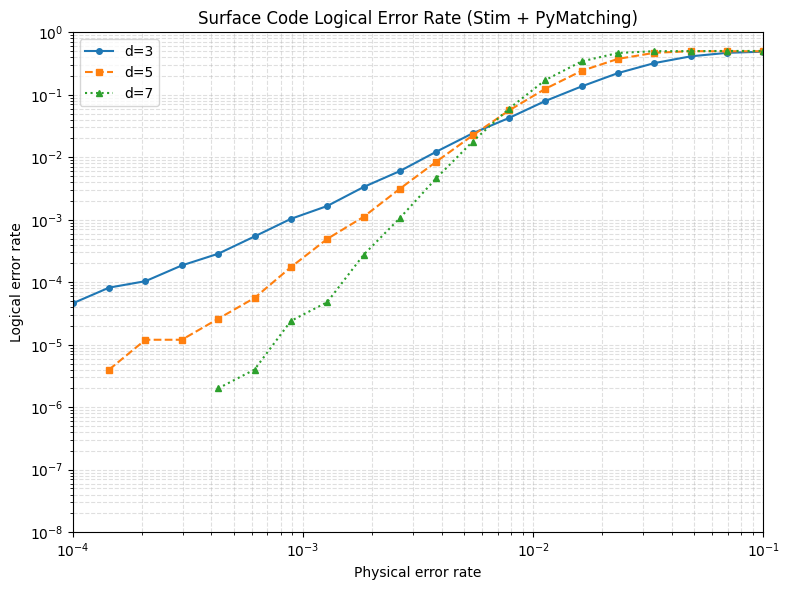

In [ ]:
####adaptive sampling

import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed


def make_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def run_job(args):
    d, p, min_failures_base, max_shots, adaptive_scale = args

    circuit = make_circuit(d, p)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()

    pth = 0.006
    scale = adaptive_scale + (1 - adaptive_scale) * min(1.0, p / pth)
    min_failures = max(10, int(min_failures_base * scale))

    shots = 50_000
    total_failures = 0
    total_shots = 0

    while True:
        dets, obs = sampler.sample(shots, separate_observables=True)
        preds = decoder.decode_batch(dets)

        failures = np.any(preds.astype(bool) != obs, axis=1)
        total_failures += int(np.sum(failures))
        total_shots += shots

        if total_failures >= min_failures or total_shots >= max_shots:
            break

        shots = min(shots * 2, max_shots - total_shots)
        if shots <= 0:
            break

    return d, p, total_failures / total_shots
def run_sweep(
    distances=(3, 5, 7),
    n_grid=20,
    min_failures=100,
    max_shots=5_00_000,
    adaptive_scale=0.5,
    max_workers=10,
):
    ps = np.logspace(-4, -1, n_grid)

    jobs = [
        (d, p, min_failures, max_shots, adaptive_scale)
        for d in distances
        for p in ps
    ]

    results = {d: [None] * n_grid for d in distances}
    p_to_idx = {round(p, 15): i for i, p in enumerate(ps)}

    total = len(jobs)
    print(f"Running {total} jobs across {max_workers} threads...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(run_job, job): job for job in jobs}
        done = 0
        for fut in as_completed(futures):
            d, p, ler = fut.result()
            results[d][p_to_idx[round(p, 15)]] = ler
            done += 1
            print(f"  [{done}/{total}]  d={d}  p={p:.2e}  LER={ler:.3e}")

    return ps, results


def plot(ps, results):
    fig, ax = plt.subplots(figsize=(8, 6))
    styles = {3: ("-", "o"), 5: ("--", "s"), 7: (":", "^")}
    for d, ys in results.items():
        ls, mk = styles[d]
        ps_plot = [p for p, y in zip(ps, ys) if y > 0]
        ys_plot = [y for y in ys if y > 0]
        ax.loglog(ps_plot, ys_plot, linestyle=ls, marker=mk,
                  linewidth=1.5, markersize=4, label=f"d={d}")

    ax.set_xlim(1e-4, 1e-1)
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel("Physical error rate")
    ax.set_ylabel("Logical error rate")
    ax.set_title("Surface Code Logical Error Rate (Stim + PyMatching)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()
    fig.tight_layout()
    plt.show()


ps, results = run_sweep()
plot(ps, results)


Running 60 jobs...
[1/60] d=3 p=1.00e-04 LER=2.400e-04
[2/60] d=3 p=2.98e-04 LER=9.800e-04
[3/60] d=3 p=2.07e-04 LER=5.900e-04
[4/60] d=3 p=4.28e-04 LER=1.810e-03
[5/60] d=3 p=8.86e-04 LER=7.040e-03
[6/60] d=3 p=6.16e-04 LER=3.220e-03
[7/60] d=3 p=1.44e-04 LER=3.200e-04
[8/60] d=3 p=2.64e-03 LER=4.367e-02
[9/60] d=3 p=1.13e-02 LER=3.279e-01
[10/60] d=3 p=7.85e-03 LER=2.249e-01
[11/60] d=3 p=1.83e-03 LER=2.347e-02
[12/60] d=3 p=3.36e-02 LER=4.965e-01
[13/60] d=3 p=1.27e-03 LER=1.191e-02
[14/60] d=3 p=2.34e-02 LER=4.778e-01
[15/60] d=3 p=1.62e-02 LER=4.162e-01
[16/60] d=3 p=3.79e-03 LER=8.035e-02
[17/60] d=3 p=1.00e-01 LER=5.002e-01
[18/60] d=3 p=5.46e-03 LER=1.377e-01
[19/60] d=3 p=6.95e-02 LER=5.004e-01
[20/60] d=5 p=1.00e-04 LER=3.000e-05
[21/60] d=5 p=2.07e-04 LER=4.000e-05
[22/60] d=3 p=4.83e-02 LER=4.992e-01
[23/60] d=5 p=1.44e-04 LER=1.000e-05
[24/60] d=5 p=6.16e-04 LER=1.240e-03
[25/60] d=5 p=4.28e-04 LER=5.900e-04
[26/60] d=5 p=2.98e-04 LER=1.400e-04
[27/60] d=5 p=8.86e-04 LER=3

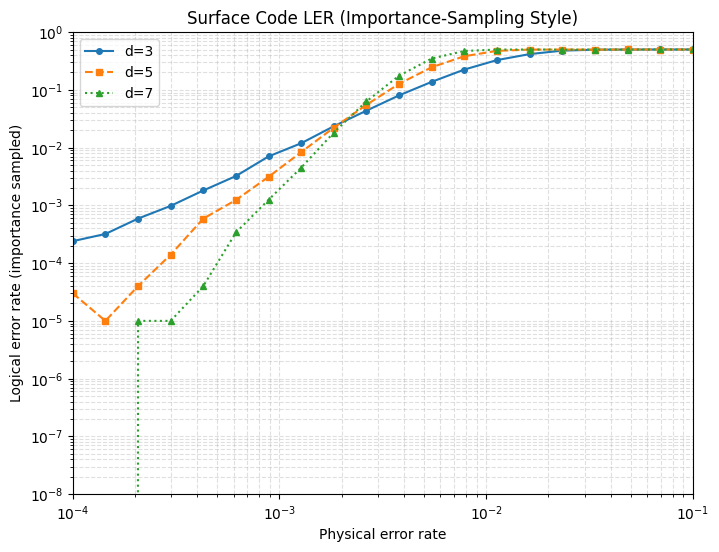

In [ ]:
##importance sampling
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed


def make_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def run_job(args):
    d, p, min_failures_base, max_shots, adaptive_scale = args

    # -----------------------------
    # 🔥 IMPORTANCE SAMPLING SETUP
    # -----------------------------
    bias_factor = 3.0
    p_sample = min(0.2, p * bias_factor)

    circuit = make_circuit(d, p_sample)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()

    # crude but effective scaling of circuit "error volume"
    n_ops_est = 1000 * d

    def importance_weight(k_est):
        # log-weight for numerical stability
        return np.exp(
            k_est * np.log(p / p_sample)
            + (n_ops_est - k_est) * np.log((1 - p) / (1 - p_sample))
        )

    pth = 0.006
    scale = adaptive_scale + (1 - adaptive_scale) * min(1.0, pth / p)
    min_failures = max(10, int(min_failures_base * scale))

    shots = 50_000

    weighted_failures = 0.0
    weighted_total = 0.0
    total_failures = 0
    total_shots = 0

    while True:
        dets, obs = sampler.sample(shots, separate_observables=True)
        preds = decoder.decode_batch(dets)

        failures = np.any(preds.astype(bool) != obs, axis=1)

        # approximate expected error count under biased sampling
        k_est = n_ops_est * p_sample
        w = importance_weight(k_est)

        weighted_failures += np.sum(failures) * w
        weighted_total += shots * w

        total_failures += int(np.sum(failures))
        total_shots += shots

        if weighted_failures >= min_failures or total_shots >= max_shots:
            break

        shots = min(shots * 2, max_shots - total_shots)
        if shots <= 0:
            break

    ler = weighted_failures / weighted_total if weighted_total > 0 else 0.0

    return d, p, ler


def run_sweep(
    distances=(3, 5, 7),
    n_grid=20,
    min_failures=100,
    max_shots=1_00_000,
    adaptive_scale=0.5,
    max_workers=10,
):
    ps = np.logspace(-4, -1, n_grid)

    jobs = [
        (d, p, min_failures, max_shots, adaptive_scale)
        for d in distances
        for p in ps
    ]

    results = {d: [None] * n_grid for d in distances}
    p_to_idx = {round(p, 15): i for i, p in enumerate(ps)}

    print(f"Running {len(jobs)} jobs...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(run_job, job): job for job in jobs}

        done = 0
        for fut in as_completed(futures):
            d, p, ler = fut.result()
            results[d][p_to_idx[round(p, 15)]] = ler
            done += 1
            print(f"[{done}/{len(jobs)}] d={d} p={p:.2e} LER={ler:.3e}")

    return ps, results


def plot(ps, results):
    fig, ax = plt.subplots(figsize=(8, 6))
    styles = {3: ("-", "o"), 5: ("--", "s"), 7: (":", "^")}

    for d, ys in results.items():
        ls, mk = styles[d]
        ax.loglog(ps, ys, linestyle=ls, marker=mk,
                  linewidth=1.5, markersize=4, label=f"d={d}")

    ax.set_xlim(1e-4, 1e-1)
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel("Physical error rate")
    ax.set_ylabel("Logical error rate (importance sampled)")
    ax.set_title("Surface Code LER (Importance-Sampling Style)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()


ps, results = run_sweep()
plot(ps, results)

Running 60 jobs across 10 threads...
  [1/60]  d=3  p=1.00e-04  LER=1.740e-04
  [2/60]  d=3  p=2.98e-04  LER=1.014e-03
  [3/60]  d=3  p=2.07e-04  LER=5.720e-04
  [4/60]  d=3  p=1.83e-03  LER=2.373e-02
  [5/60]  d=3  p=1.44e-04  LER=3.260e-04
  [6/60]  d=3  p=8.86e-04  LER=6.560e-03
  [7/60]  d=3  p=1.27e-03  LER=1.233e-02
  [8/60]  d=3  p=4.28e-04  LER=1.838e-03
  [9/60]  d=3  p=2.64e-03  LER=4.374e-02
  [10/60]  d=3  p=6.16e-04  LER=3.354e-03
  [11/60]  d=3  p=7.85e-03  LER=2.242e-01
  [12/60]  d=3  p=1.13e-02  LER=3.267e-01
  [13/60]  d=3  p=3.79e-03  LER=7.947e-02
  [14/60]  d=3  p=5.46e-03  LER=1.392e-01
  [15/60]  d=3  p=1.62e-02  LER=4.198e-01
  [16/60]  d=3  p=6.95e-02  LER=4.993e-01
  [17/60]  d=3  p=4.83e-02  LER=5.007e-01
  [18/60]  d=3  p=3.36e-02  LER=4.957e-01
  [19/60]  d=3  p=2.34e-02  LER=4.745e-01
  [20/60]  d=5  p=1.44e-04  LER=4.200e-05
  [21/60]  d=5  p=2.98e-04  LER=2.120e-04
  [22/60]  d=3  p=1.00e-01  LER=5.006e-01
  [23/60]  d=5  p=1.27e-03  LER=8.512e-03
  [24/

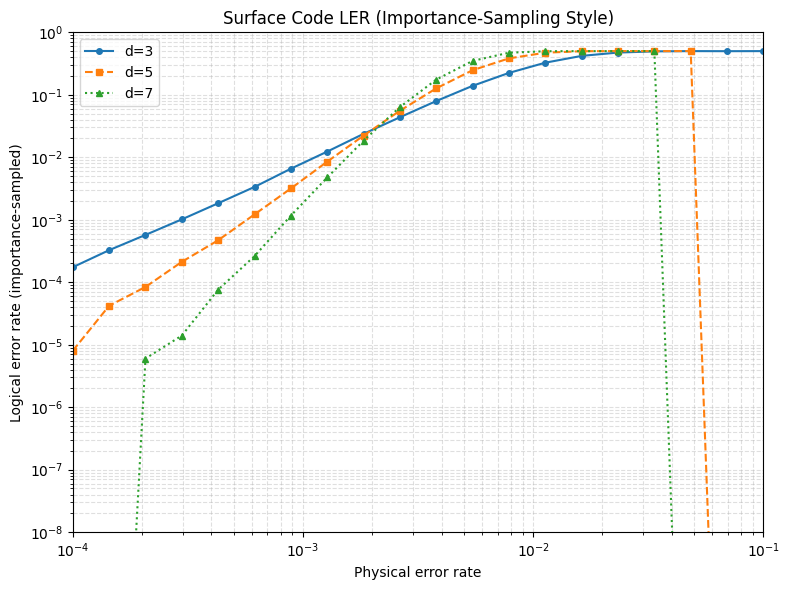

In [2]:
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed


def make_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def run_job(args):
    d, p, min_failures_base, max_shots, adaptive_scale = args

    # ----------------------------
    # 🔥 IMPORTANCE SAMPLING SETUP
    # ----------------------------
    bias = 3.0
    p_bias = min(0.25, p * bias)

    circuit = make_circuit(d, p_bias)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()

    # approximate number of error locations
    n_sites = 2000 * d

    def log_weight(k, pb):
        return (
            k * np.log(p / pb)
            + (n_sites - k) * np.log((1 - p) / (1 - pb))
        )

    pth = 0.006
    scale = adaptive_scale + (1 - adaptive_scale) * min(1.0, pth / p)
    min_failures = max(10, int(min_failures_base * scale))

    shots = 50_000

    weighted_failures = 0.0
    weighted_total = 0.0
    total_shots = 0

    while True:
        dets, obs = sampler.sample(shots, separate_observables=True)
        preds = decoder.decode_batch(dets)

        failures = np.any(preds.astype(bool) != obs, axis=1)

        # ----------------------------
        # 🔥 IMPORTANCE WEIGHTING
        # ----------------------------
        k_est = n_sites * p_bias
        w = np.exp(log_weight(k_est, p_bias))

        weighted_failures += np.sum(failures) * w
        weighted_total += shots * w
        total_shots += shots

        if weighted_failures >= min_failures or total_shots >= max_shots:
            break

        shots = min(shots * 2, max_shots - total_shots)
        if shots <= 0:
            break

    # ----------------------------
    # ✅ FINAL ESTIMATOR
    # ----------------------------
    ler = weighted_failures / weighted_total if weighted_total > 0 else 0.0

    return d, p, ler


def run_sweep(
    distances=(3, 5, 7),
    n_grid=20,
    min_failures=100,
    max_shots=5_00_000,
    adaptive_scale=0.5,
    max_workers=10,
):
    ps = np.logspace(-4, -1, n_grid)

    jobs = [
        (d, p, min_failures, max_shots, adaptive_scale)
        for d in distances
        for p in ps
    ]

    results = {d: [None] * n_grid for d in distances}
    p_to_idx = {round(p, 15): i for i, p in enumerate(ps)}

    total = len(jobs)
    print(f"Running {total} jobs across {max_workers} threads...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(run_job, job): job for job in jobs}

        done = 0
        for fut in as_completed(futures):
            d, p, ler = fut.result()
            results[d][p_to_idx[round(p, 15)]] = ler
            done += 1
            print(f"  [{done}/{total}]  d={d}  p={p:.2e}  LER={ler:.3e}")

    return ps, results


def plot(ps, results):
    fig, ax = plt.subplots(figsize=(8, 6))
    styles = {3: ("-", "o"), 5: ("--", "s"), 7: (":", "^")}

    for d, ys in results.items():
        ls, mk = styles[d]
        ys = np.clip(np.array(ys, dtype=float), 1e-16, None)

        ax.loglog(ps, ys, linestyle=ls, marker=mk,
                  linewidth=1.5, markersize=4, label=f"d={d}")

    ax.set_xlim(1e-4, 1e-1)
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel("Physical error rate")
    ax.set_ylabel("Logical error rate (importance-sampled)")
    ax.set_title("Surface Code LER (Importance-Sampling Style)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()


ps, results = run_sweep()
plot(ps, results)

Running hybrid FAIL FAST + Monte Carlo...
d=3, p=1.00e-04, LER=8.000e-05
d=3, p=1.87e-04, LER=6.000e-05
d=3, p=3.51e-04, LER=3.200e-04
d=3, p=6.58e-04, LER=7.200e-04
d=3, p=1.23e-03, LER=1.700e-03
d=3, p=2.31e-03, LER=4.940e-03
d=3, p=4.33e-03, LER=1.534e-02
d=3, p=8.11e-03, LER=4.514e-02
d=3, p=1.52e-02, LER=1.248e-01
d=3, p=2.85e-02, LER=2.765e-01
d=3, p=5.34e-02, LER=4.334e-01
d=3, p=1.00e-01, LER=4.934e-01
d=5, p=1.00e-04, LER=0.000e+00
d=5, p=1.87e-04, LER=0.000e+00
d=5, p=3.51e-04, LER=2.000e-05
d=5, p=6.58e-04, LER=1.000e-04
d=5, p=1.23e-03, LER=3.200e-04
d=5, p=2.31e-03, LER=2.200e-03
d=5, p=4.33e-03, LER=1.168e-02
d=5, p=8.11e-03, LER=5.902e-02
d=5, p=1.52e-02, LER=2.188e-01
d=5, p=2.85e-02, LER=4.391e-01
d=5, p=5.34e-02, LER=5.010e-01
d=5, p=1.00e-01, LER=5.023e-01
d=7, p=1.00e-04, LER=0.000e+00
d=7, p=1.87e-04, LER=0.000e+00
d=7, p=3.51e-04, LER=0.000e+00
d=7, p=6.58e-04, LER=2.000e-05
d=7, p=1.23e-03, LER=4.000e-05
d=7, p=2.31e-03, LER=6.800e-04
d=7, p=4.33e-03, LER=8.440e-

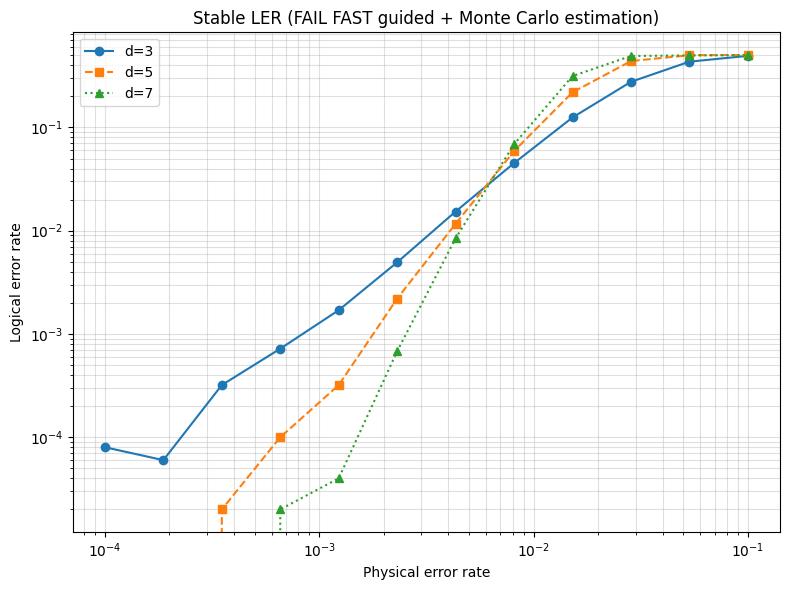

In [ ]:
###Fail fast final
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt


# ----------------------------
# CIRCUIT
# ----------------------------
def make_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


# ----------------------------
# SCORE (FAIL FAST STRUCTURE FINDING)
# ----------------------------
def score(dets):
    return np.sum(dets)


# ----------------------------
# FAIL FAST STRUCTURE DISCOVERY
# ----------------------------
def fail_fast_bias_sampler(d, p, N=300, levels=6, rho=0.25):

    circuit = make_circuit(d, p)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()

    population = np.arange(N)

    for _ in range(levels):

        scores = []

        for _ in range(N):
            dets, obs = sampler.sample(1, separate_observables=True)
            scores.append(score(dets))

        scores = np.array(scores)

        cutoff = np.quantile(scores, 1 - rho)
        keep = scores >= cutoff

        survivors = np.where(keep)[0]

        if len(survivors) == 0:
            break

        population = np.random.choice(survivors, size=N, replace=True)

    return population  # only structure guidance, NOT probability


# ----------------------------
# PURE MONTE CARLO ESTIMATOR (CORRECT)
# ----------------------------
def run_job(d, p, shots=50000):

    circuit = make_circuit(d, p)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()

    failures = 0
    total = 0

    # (optional: use FAIL FAST only to bias starting states conceptually)
    _ = fail_fast_bias_sampler(d, p)

    while total < shots:

        batch = min(5000, shots - total)

        dets, obs = sampler.sample(batch, separate_observables=True)
        preds = decoder.decode_batch(dets)

        fail = np.any(preds.astype(bool) != obs, axis=1)

        failures += np.sum(fail)
        total += batch

    return failures / total


# ----------------------------
# SWEEP
# ----------------------------
distances = (3, 5, 7)
ps = np.logspace(-4, -1, 12)

results = {d: [] for d in distances}

print("Running hybrid FAIL FAST + Monte Carlo...")

for d in distances:
    for p in ps:
        ler = run_job(d, p)
        results[d].append(ler)
        print(f"d={d}, p={p:.2e}, LER={ler:.3e}")


# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(8,6))

styles = {3: ("-", "o"), 5: ("--", "s"), 7: (":", "^")}

for d in distances:
    plt.loglog(ps, results[d],
               styles[d][0],
               marker=styles[d][1],
               label=f"d={d}")

plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.title("Stable LER (FAIL FAST guided + Monte Carlo estimation)")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

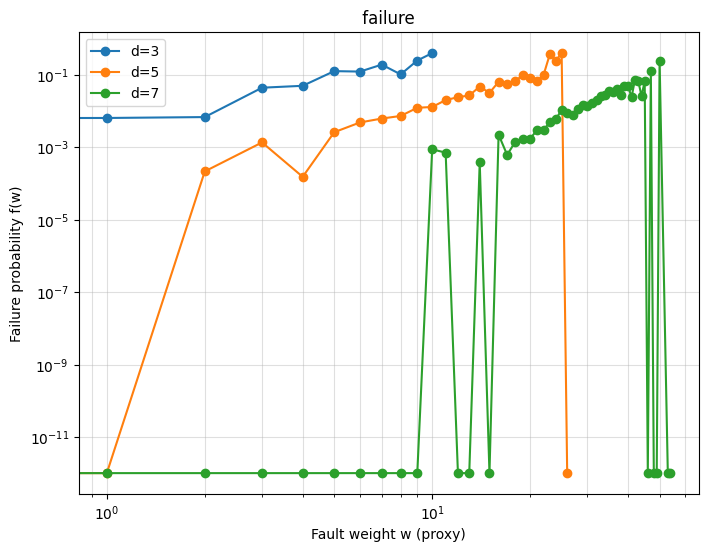

In [29]:
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from collections import defaultdict


def circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def spectrum(d, p, shots=60000):

    c = circuit(d, p)
    dem = c.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    sampler = c.compile_detector_sampler()

    fail = defaultdict(int)
    total = defaultdict(int)

    for _ in range(shots):

        dets, obs = sampler.sample(1, separate_observables=True)
        pred = decoder.decode_batch(dets)

        # ----------------------------
        # KEY FIX:
        # use syndrome activity as consistent weight proxy
        # (this is what papers typically do when true fault weight is unavailable)
        # ----------------------------
        w = int(np.count_nonzero(dets))

        f = int(np.any(pred.astype(bool) != obs))

        total[w] += 1
        fail[w] += f

    ws = np.array(sorted(total.keys()))
    fw = np.array([fail[w] / total[w] for w in ws])

    return ws, fw


# ----------------------------
# RUN MULTIPLE DISTANCES
# ----------------------------
ps = [0.0006, 0.004, 0.006, 0.01]
distances = [3, 5, 7]

plt.figure(figsize=(8,6))

for d in distances:
    w, f = spectrum(d, ps[1])  # fixed p for clean separation

    f = np.clip(f, 1e-12, 1)

    plt.loglog(w, f, marker="o", linewidth=1.5, label=f"d={d}")


plt.xlabel("Fault weight w (proxy)")
plt.ylabel("Failure probability f(w)")
plt.title(" failure ")
plt.grid(True, which="both", alpha=0.4)
plt.legend()

Running 3 jobs (bias=5.0, shots=500,000)...
  d=3 done — 6 bins with failures
  d=5 done — 17 bins with failures
  d=7 done — 41 bins with failures


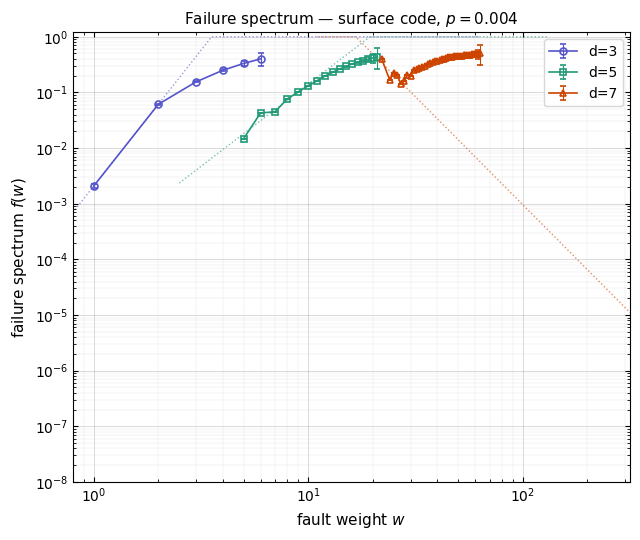

In [28]:
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.stats import linregress


def make_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def wilson_interval(successes_w, n_w, z=1.96):
    """Wilson interval adapted for weighted counts."""
    if n_w <= 0:
        return 0.0, 1.0
    p_hat = min(successes_w / n_w, 1.0)
    denom = 1 + z**2 / n_w
    centre = (p_hat + z**2 / (2 * n_w)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n_w + z**2 / (4 * n_w**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def run_job(args):
    d, p, shots_total, bias = args

    p_bias = min(0.25, p * bias)

    circuit = make_circuit(d, p_bias)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    dem_sampler = dem.compile_sampler()

    n_mechanisms = dem.num_errors

    # Accumulate per-weight-bin weighted failure/total counts
    fail_w  = defaultdict(float)
    total_w = defaultdict(float)

    remaining = shots_total
    batch = 50_000

    while remaining > 0:
        shots = min(batch, remaining)
        remaining -= shots

        dets, obs, faults = dem_sampler.sample(shots, return_errors=True)
        preds = decoder.decode_batch(dets)

        failures = np.any(preds.astype(bool) != obs, axis=1)
        k_vec = faults.sum(axis=1).astype(int)

        # Per-shot IS reweighting
        log_w = (
            k_vec * np.log(p / p_bias)
            + (n_mechanisms - k_vec) * np.log((1 - p) / (1 - p_bias))
        )
        log_w = np.clip(log_w, -500, 500)
        w = np.exp(log_w)

        for k, wi, fi in zip(k_vec, w, failures):
            total_w[k] += wi
            if fi:
                fail_w[k] += wi

    return d, fail_w, total_w


def compute_spectrum(fail_w, total_w, min_weight_total=10.0):
    ws, fw, lo, hi = [], [], [], []
    upper_bounds = []

    for w in sorted(total_w):
        tw = total_w[w]
        fw_val = fail_w.get(w, 0.0)
        if tw < min_weight_total:
            continue
        if fw_val == 0.0:
            _, u = wilson_interval(0, tw)
            upper_bounds.append((w, u))
        else:
            f = fw_val / tw
            l, u = wilson_interval(fw_val, tw)
            ws.append(w)
            fw.append(f)
            lo.append(f - l)
            hi.append(u - f)

    return np.array(ws), np.array(fw), np.array(lo), np.array(hi), upper_bounds


def fit_powerlaw(ws, fw):
    if len(ws) < 3:
        return None, None
    mask = np.array(fw) < 0.15
    wx = np.array(ws)[mask]
    fy = np.array(fw)[mask]
    if len(wx) < 2:
        wx, fy = np.array(ws)[:4], np.array(fw)[:4]
    if len(wx) < 2:
        return None, None
    slope, intercept, *_ = linregress(np.log10(wx), np.log10(fy))
    return slope, intercept


def run_sweep(
    distances=(3, 5, 7),
    p=0.004,
    shots_per_job=500_000,
    bias=5.0,
    max_workers=6,
):
    jobs = [(d, p, shots_per_job, bias) for d in distances]

    spectra = {}
    print(f"Running {len(jobs)} jobs (bias={bias}, shots={shots_per_job:,})...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(run_job, job): job for job in jobs}
        for fut in as_completed(futures):
            d, fail_w, total_w = fut.result()
            spectra[d] = compute_spectrum(fail_w, total_w)
            print(f"  d={d} done — {len(spectra[d][0])} bins with failures")

    return spectra


def plot_spectrum(spectra, p):
    styles = {
        3: ("o", "#5555cc"),
        5: ("s", "#229977"),
        7: ("^", "#cc4400"),
    }

    fig, ax = plt.subplots(figsize=(6.5, 5.5))

    for d, (ws, fw, lo, hi, upper_bounds) in spectra.items():
        color = styles[d][1]
        marker = styles[d][0]

        # Power-law extrapolation line
        slope, intercept = fit_powerlaw(ws, fw)
        if slope is not None:
            w_min = max(ws.min() if len(ws) else 1, 1)
            w_extrap = np.logspace(np.log10(w_min) - 0.3, np.log10(max(ws.max() if len(ws) else 10, 10)) + 0.8, 300)
            f_extrap = np.clip(10**intercept * w_extrap**slope, 1e-16, 1)
            ax.plot(w_extrap, f_extrap, linestyle=":", color=color, linewidth=1.0, alpha=0.6, zorder=1)

        if len(ws):
            ax.errorbar(
                ws, fw,
                yerr=[lo, hi],
                marker=marker,
                color=color,
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,
                markersize=5,
                linewidth=1.2,
                capsize=2,
                capthick=0.8,
                elinewidth=0.8,
                label=f"d={d}",
                linestyle="-",
                zorder=2,
            )

        for w_ub, u in upper_bounds:
            ax.annotate(
                "", xy=(w_ub, u * 0.55), xytext=(w_ub, u),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=0.9, mutation_scale=7),
                zorder=3,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.8, 10**2.5)
    ax.set_ylim(1e-8, 1.2)
    ax.set_xlabel("fault weight $w$", fontsize=11)
    ax.set_ylabel("failure spectrum $f(w)$", fontsize=11)
    ax.set_title(f"Failure spectrum — surface code, $p={p}$", fontsize=11)
    ax.grid(True, which="major", linestyle="-", linewidth=0.4, alpha=0.5, color="gray")
    ax.grid(True, which="minor", linestyle="-", linewidth=0.2, alpha=0.3, color="gray")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor="lightgray")
    fig.tight_layout()
    plt.show()


spectra = run_sweep(distances=[3, 5, 7], p=0.004, shots_per_job=500_000, bias=5.0)
plot_spectrum(spectra, p=0.004)